In [3]:
import ast
import pandas as pd
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt
from datasets import load_dataset

datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_Ind = df[df['job_country']=='India'].dropna(subset=['salary_year_avg'])

In [5]:
job_titles = df_Ind['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [14]:
df_Ind_top6 = df_Ind[df_Ind['job_title_short'].isin(job_titles)]
df_title_order = df_Ind_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

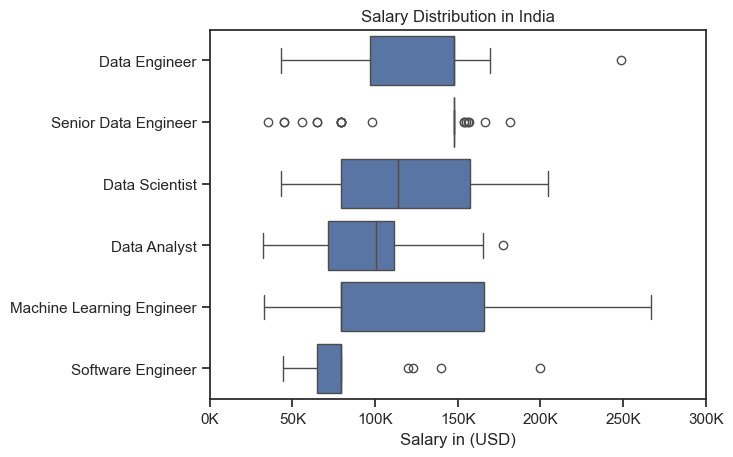

In [16]:
sbs.boxplot(data=df_Ind_top6, x='salary_year_avg', y='job_title_short', order=df_title_order)
sbs.set_theme(style='ticks')

plt.title('Salary Distribution in India')
plt.xlabel('Salary in (USD)')
plt.ylabel('')
plt.xlim(0,300000)
ticks_x = plt.FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [23]:
df_Ind = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Scientist')].copy()
df_Ind_ds = df_Ind.dropna(subset=['salary_year_avg'])

In [24]:
df_Ind_ds = df_Ind_ds.explode('job_skills')
df_Ind_ds[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
3930,114516.0,python
3930,114516.0,r
3930,114516.0,c++
3930,114516.0,tensorflow
3930,114516.0,tableau


In [27]:
df_top_pay = df_Ind_ds.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False)
df_top_pay = df_top_pay.head(10)

In [31]:
df_most_pop = df_Ind_ds.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count',ascending=False )
df_most_pop = df_most_pop.head(10).sort_values(by='median',ascending=False)
df_most_pop

,count,median
job_skills,,
azure,15,157500.00
pytorch,10,157500.00
python,64,152500.00
tensorflow,16,136008.00
r,30,129758.00
sql,49,113500.00
tableau,19,113500.00
aws,20,103550.00
spark,23,93600.00


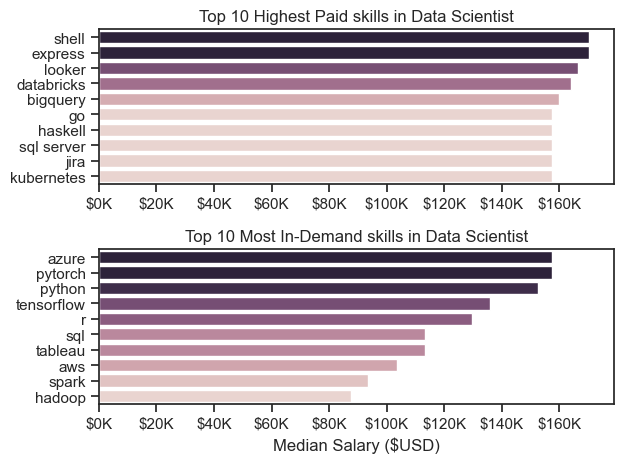

In [32]:
fig, ax = plt.subplots(2,1)

sbs.set_theme(style="ticks")

sbs.barplot(data=df_top_pay, x='median', y=df_top_pay.index, ax=ax[0], hue='median')
ax[0].legend().remove()
#df_US_pay[::-1].plot(kind='barh', y='median',ax= ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid skills in Data Scientist')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

sbs.barplot(data=df_most_pop, x='median', y=df_most_pop.index, ax=ax[1], hue='median')
ax[1].legend().remove()
#df_US_skill[::-1].plot(kind='barh', y='median', ax= ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand skills in Data Scientist')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

fig.tight_layout()